[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sk-2103/AI4Sustainability-Labs/blob/main/labs/lab04_cnn_surface_water/lab04_cnn_surface_water.ipynb)  
**AI for Sustainability** · University of Wisconsin–Madison · Labs by Saurabh Kaushik · Course instructor: Dr. Beth Tellman  
*Make a copy (File → Save a copy in Drive) before you start. Part of the [AI for Sustainability lab series](https://github.com/Sk-2103/AI4Sustainability-Labs).*

# Lab 4: CNNs for Surface Water Mapping (Segmentation) with TorchGeo

**Audience:** Undergraduate  
**Theme:** Sustainability + water monitoring from satellites  
**Core flow:** **NDWI baseline → Tiny CNN → U‑Net (TorchGeo model)**

This lab is based on TorchGeo’s *Earth Surface Water* tutorial (simplified for teaching).  
Reference: https://torchgeo.readthedocs.io/en/stable/tutorials/earth_surface_water.html

---

## Learning objectives (ranked)

1. Understand CNN concepts **visually** (filters, channels, receptive field, pooling/stride/padding).
2. Run a **real remote sensing dataset** (patch sampling).
3. Build & train a **U‑Net** for segmentation.
4. Compare CNN results to a classic **NDWI** baseline.

---

## Where does Colab download data?

You control the download/extract folder via `DATA_ROOT`:

- `/content/surface_water` (visible in Colab Files; ephemeral)
- `/tmp/surface_water` (fastest; ephemeral)
- `/content/drive/MyDrive/surface_water` (persistent; recommended for teaching)


In [ ]:
# ── Install dependencies (only needed once per Colab session) ─────────────────
# If running locally and packages are already installed, this is safe to skip.
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['torchgeo', 'rasterio', 'scikit-learn', 'scipy']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

print('✅ All packages ready')

Installing scikit-learn...
✅ All packages ready


## 0) Setup

If you are in Colab, run the install cell once.


In [ ]:
# Colab install (uncomment if needed)
# !pip -q install torchgeo rasterio scikit-learn matplotlib kornia

import os, math, random, tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import rasterio as rio

from torchgeo.datasets import RasterDataset, stack_samples, unbind_samples, utils
from torchgeo.samplers import RandomGeoSampler, Units

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.10.0+cpu
cuda available: False


## 1) Download Earth Surface Water dataset

We download and extract the dataset zip and point `root` to the extracted folder (`dset-s2`).


In [ ]:
# Choose a data root
DATA_ROOT = Path("/content/surface_water")  #
# DATA_ROOT = Path("/tmp/surface_water")    # faster
# from google.colab import drive; drive.mount("/content/drive")
# DATA_ROOT = Path("/content/drive/MyDrive/surface_water")  # persistent

DATA_ROOT.mkdir(parents=True, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT)

zip_url = "https://hf.co/datasets/cordmaur/earth_surface_water/resolve/main/earth_surface_water.zip"
utils.download_and_extract_archive(zip_url, DATA_ROOT)

root = DATA_ROOT / "dset-s2"
print("Dataset root:", root)
print("Folders:", sorted([p.name for p in root.iterdir() if p.is_dir()]))


DATA_ROOT: /content/surface_water
Dataset root: /content/surface_water/dset-s2
Folders: ['tra_scene', 'tra_truth', 'val_scene', 'val_truth']


---
# Part 1 — How Satellites See Water

## 1.1 Light beyond what our eyes can see

Landsat 8 records **6 bands of light**, from visible colors to invisible infrared:

```
  Wavelength  →  shorter ─────────────────────────────────── longer

  Human eye:       Blue   Green   Red  |  (invisible to us beyond here)
                   ───────────────────────────────────────────────────
  Landsat bands:    B2     B3     B4      B5      B6      B7
                   Blue  Green   Red    NIR    SWIR1   SWIR2
```

## 1.2 The key physics fact

**Water absorbs almost all Near-Infrared (NIR) light.** This means:

| Material | How it appears in the NIR band |
|----------|---------------------------------|
| Open water | Very **dark** (absorbs NIR) |
| Vegetation | Very **bright** (reflects NIR strongly) |
| Bare soil | Medium brightness |
| Urban/roads | Medium-dark |

This gives us a simple physics-based detector — the **NDWI**:

$$\boxed{\text{NDWI} = \frac{\text{Green} - \text{NIR}}{\text{Green} + \text{NIR}}}$$

High NDWI → water. Low NDWI → land. No training required.

Later our CNN will use **all 6 bands together**, learning patterns the formula can't capture — like distinguishing shallow muddy water from bare soil, or handling cloud shadows.

---
# Part 2 — How a CNN "Sees"

Before writing model code, let's build the intuition visually.

## 2.1 The four core operations

Every CNN — from the simplest to GPT-4's image encoder — is built from these four ideas:

---

### 🔲 Operation 1: Convolution — "What pattern is here?"

A small grid of numbers (a **kernel** or **filter**) slides across the image. At each position, it multiplies its weights by the image pixels underneath and sums them up. The result is a **feature map** — a new image that highlights wherever that pattern occurred.

```
  Image patch           Kernel (3×3)        Feature map
  ┌─────────────┐       ┌──────────┐        ┌──────────┐
  │ 0.1 0.1 0.8 │       │ -1  0  1 │        │          │
  │ 0.1 0.1 0.8 │  ✕   │ -2  0  2 │  →     │ (bright  │
  │ 0.1 0.1 0.8 │       │ -1  0  1 │        │  edges)  │
  └─────────────┘       └──────────┘        └──────────┘
     (land|water                                (water edge
      boundary)                                  detected!)
```

**Crucially: the CNN *learns* these kernels.** We don't hand-design them. After training, some kernels detect edges, others detect dark-NIR patches (water), others detect texture differences.


![CNN Operations](https://drive.google.com/uc?export=download&id=1P27dlVZKFeaivLvcubanQmCP1dDWyuat)

---

### 📊 Operation 2: ReLU — "Keep only positive signals"

After convolution, we apply: **f(x) = max(0, x)**

Any negative feature map value → set to 0. Positive values → kept as-is.

Without this, stacking multiple conv layers would be equivalent to just one linear operation. ReLU introduces **non-linearity** — the ability to learn complex, curved decision boundaries.

---

### 📐 Operation 3: Batch Normalization — "Stabilize the numbers"

After each conv layer, activations can grow very large or very small, making training unstable. BatchNorm rescales them to have mean ≈ 0 and standard deviation ≈ 1.

Think of it like standardizing test scores — it keeps everything on the same scale so the next layer can learn reliably.

---

### 🔍 Operation 4: Max Pooling — "Zoom out, keep what matters"

Takes the maximum value in each small window, shrinking the image by 2×. This compresses spatial information and makes the model less sensitive to exact pixel positions (a water pixel one pixel to the left should still be detected as water).

## 2) Build TorchGeo datasets: images + masks + intersection

TorchGeo uses `RasterDataset` for imagery and masks.  
We set a single CRS **EPSG:3395** (World Mercator) to handle global patches.


In [ ]:
def scale(item: dict):
    # Sentinel‑2 reflectance scaling (1e‑4)
    item["image"] = item["image"] / 10000.0
    return item

train_imgs = RasterDataset(paths=(root / "tra_scene").as_posix(), crs="epsg:3395", res=10, transforms=scale)
train_msks = RasterDataset(paths=(root / "tra_truth").as_posix(), crs="epsg:3395", res=10)

valid_imgs = RasterDataset(paths=(root / "val_scene").as_posix(), crs="epsg:3395", res=10, transforms=scale)
valid_msks = RasterDataset(paths=(root / "val_truth").as_posix(), crs="epsg:3395", res=10)

train_msks.is_image = False
valid_msks.is_image = False

train_dset = train_imgs & train_msks
valid_dset = valid_imgs & valid_msks

PATCH = 256
TRAIN_LEN = 96
VAL_LEN = 32

train_sampler = RandomGeoSampler(train_imgs, size=PATCH, length=TRAIN_LEN, units=Units.PIXELS)
valid_sampler = RandomGeoSampler(valid_imgs, size=PATCH, length=VAL_LEN, units=Units.PIXELS)

train_loader = DataLoader(train_dset, sampler=train_sampler, batch_size=4, collate_fn=stack_samples, num_workers=0)
valid_loader = DataLoader(valid_dset, sampler=valid_sampler, batch_size=4, collate_fn=stack_samples, num_workers=0)

batch = next(iter(train_loader))
print(batch.keys())
print("image:", batch["image"].shape)  # (B,C,H,W)
print("mask :", batch["mask"].shape)   # (B,1,H,W)


dict_keys(['bounds', 'transform', 'image', 'mask'])
image: torch.Size([4, 6, 256, 256])
mask : torch.Size([4, 256, 256])


## 3) Visualize a batch (RGB + mask)

For visualization we assume channels are `[B2,B3,B4,B8,B11,B12]` and use RGB = `[B4,B3,B2]` = indices `[2,1,0]`.


Collected 16 samples with water >= 1.00% (scanned 7 batches).


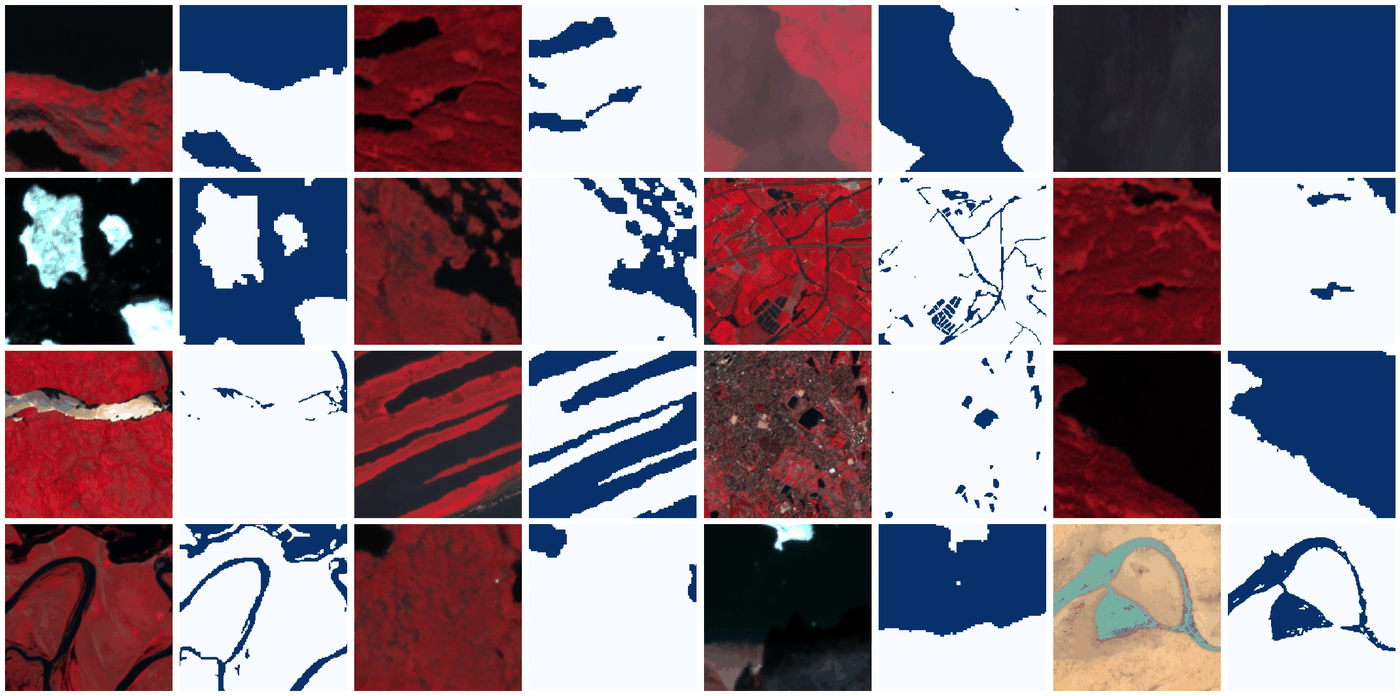

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchgeo.datasets import stack_samples, unbind_samples

# ---------- plotting helpers ----------
def plot_imgs(images, axs, chnls=[3,2,1], bright=2.0):
    for img, ax in zip(images, axs):
        arr = torch.clamp(bright * img, min=0, max=1).cpu().numpy()
        rgb = arr.transpose(1,2,0)[:, :, chnls]
        ax.imshow(rgb)
        ax.axis("off")

def plot_msks(masks, axs):
    for mask, ax in zip(masks, axs):
        ax.imshow(mask.squeeze().cpu().numpy(), cmap="Blues")
        ax.axis("off")

def plot_batch(batch, cols=8, width=3.5, bright=2.0, chnls=[3,2,1]):
    samples = unbind_samples(batch.copy())
    n = 2 * len(samples)
    rows = n // cols + (1 if n % cols else 0)

    fig, axs = plt.subplots(rows, cols, figsize=(cols*width, rows*width))
    axs = np.array(axs).reshape(-1)

    plot_imgs((s["image"] for s in samples), axs[::2], chnls=chnls, bright=bright)
    plot_msks((s["mask"] for s in samples), axs[1::2])

    # hide unused axes
    for ax in axs[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# ---------- water-rich sampling ----------
def water_fraction(sample):
    m = sample["mask"]
    if m.ndim == 3:
        m = m.squeeze(0)
    m = m.cpu()
    return float((m > 0).sum().item() / m.numel())

def collect_water_rich_batch(loader, target_samples=16, min_water_frac=0.01, max_batches_to_scan=200):
    kept = []
    scanned = 0

    for b in loader:
        scanned += 1
        for s in unbind_samples(b.copy()):
            if water_fraction(s) >= min_water_frac:
                kept.append(s)
            if len(kept) >= target_samples:
                break
        if len(kept) >= target_samples or scanned >= max_batches_to_scan:
            break

    if len(kept) == 0:
        raise RuntimeError("No water-rich patches found. Lower min_water_frac or scan more batches.")

    print(f"Collected {len(kept)} samples with water >= {min_water_frac*100:.2f}% (scanned {scanned} batches).")
    return stack_samples(kept)

viz_batch = collect_water_rich_batch(train_loader, target_samples=16, min_water_frac=0.01)
plot_batch(viz_batch, cols=8, width=3.5, bright=2.0, chnls=[3,2,1])

## 4) CNN concepts (visual + hands-on)

### What is a convolution?
A CNN layer slides a small kernel across an image to compute a new feature map.  
Different kernels learn to detect different patterns (edges, textures, water-like spectral signatures).

### Visual resources (optional)
- Convolution arithmetic (padding/stride): https://github.com/vdumoulin/conv_arithmetic  
- Feature visualization intuition: https://distill.pub/2017/feature-visualization/


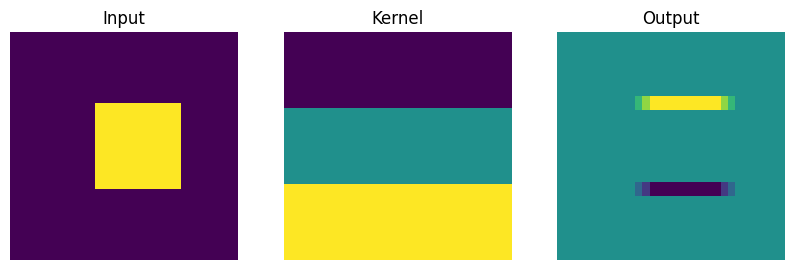

In [ ]:
# Toy convolution demo: see how a filter responds to edges
img = torch.zeros(1, 1, 32, 32)
img[:, :, 10:22, 12:24] = 1.0

kernel = torch.tensor([[
    [-1.0, -1.0, -1.0],
    [ 0.0,  0.0,  0.0],
    [ 1.0,  1.0,  1.0],
]], dtype=torch.float32).unsqueeze(0)

out = F.conv2d(img, kernel, padding=1)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].imshow(img[0,0]); axs[0].set_title("Input"); axs[0].axis("off")
axs[1].imshow(kernel[0,0]); axs[1].set_title("Kernel"); axs[1].axis("off")
axs[2].imshow(out[0,0]); axs[2].set_title("Output"); axs[2].axis("off")
plt.show()


## 5) NDWI baseline

NDWI = (Green − NIR) / (Green + NIR).  
For `[B2,B3,B4,B8,B11,B12]`: Green=1, NIR=3.


Found water-rich patch after scanning 1 batches (water=6.06%)
NDWI IoU: 0.0


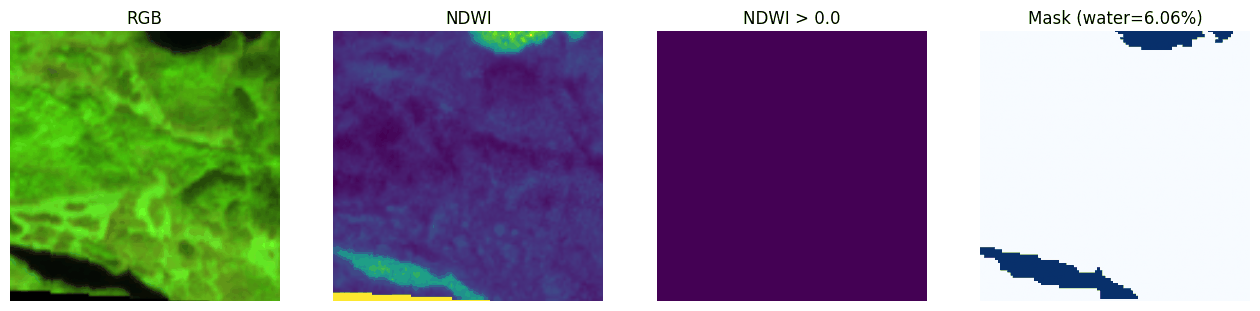

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def compute_ndwi(x_chw, green=1, nir=3, eps=1e-6):
    g = x_chw[green].float()
    n = x_chw[nir].float()
    return (g - n) / (g + n + eps)

def iou(pred, target, eps=1e-6):
    pred = pred.bool()
    target = target.bool()
    inter = (pred & target).sum().item()
    union = (pred | target).sum().item()
    return inter / (union + eps)

def find_water_rich_sample(loader, min_water_frac=0.1, max_batches=200):
    """
    Returns (x_chw, y_hw, water_frac) for the first sample with enough water.
    Uses y > 0 as water (robust to 0/1 or 0/255 masks).
    """
    scanned = 0
    for b in loader:
        scanned += 1
        x = b["image"]  # (B,C,H,W)
        y = b["mask"]   # (B,H,W) or (B,1,H,W)

        # Normalize y to (B,H,W)
        if y.ndim == 4:
            y2 = y[:, 0]
        else:
            y2 = y

        # Compute water fraction per sample
        water_frac = (y2 > 0).float().mean(dim=(1, 2))  # (B,)

        # Find an index meeting threshold
        idx = torch.where(water_frac >= min_water_frac)[0]
        if len(idx) > 0:
            j = int(idx[0].item())
            print(f"Found water-rich patch after scanning {scanned} batches "
                  f"(water={water_frac[j].item()*100:.2f}%)")
            return x[j], y2[j], float(water_frac[j].item())

        if scanned >= max_batches:
            break

    raise RuntimeError(
        f"No water-rich samples found with min_water_frac={min_water_frac}. "
        f"Try lowering it (e.g., 0.005 or 0.001) or increase max_batches."
    )

# ---- pick a patch that contains water ----
x, y, wf = find_water_rich_sample(train_loader, min_water_frac=0.01, max_batches=300)

# ---- NDWI on that patch ----
ndwi = compute_ndwi(x, green=1, nir=3)

thr = 0.0
ndwi_mask = (ndwi > thr)

print("NDWI IoU:", iou(ndwi_mask, y))

# ---- visualize ----
rgb = x[[4, 3, 2]].float()  #
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
rgb = rgb.permute(1, 2, 0).cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(rgb);                 axs[0].set_title("RGB"); axs[0].axis("off")
axs[1].imshow(ndwi.cpu().numpy());  axs[1].set_title("NDWI"); axs[1].axis("off")
axs[2].imshow(ndwi_mask.cpu().numpy()); axs[2].set_title(f"NDWI > {thr}"); axs[2].axis("off")
axs[3].imshow(y.cpu().numpy(), cmap="Blues"); axs[3].set_title(f"Mask (water={wf*100:.2f}%)"); axs[3].axis("off")
plt.show()

## 6) Tiny CNN from scratch (segmentation)

A minimal fully convolutional model outputs 1 logit per pixel (water probability after sigmoid).


In [ ]:
# -----------------------------
# Tiny CNN segmentation baseline (COMPLETE corrected cell)
# Fixes mask shape mismatch for BCEWithLogitsLoss
# -----------------------------

import numpy as np
import torch
import torch.nn as nn

class TinySegCNN(nn.Module):
    def __init__(self, in_ch: int, base: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, base, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, base, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, 1, 1),  # (B,1,H,W) logits
        )

    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
C = batch["image"].shape[1]
tiny = TinySegCNN(in_ch=C).to(device)

crit = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(tiny.parameters(), lr=1e-3)

def batch_xy(b):
    x = b["image"].float()  # (B,C,H,W)

    y = b["mask"]           # could be (B,H,W) or (B,1,H,W)
    if y.ndim == 3:
        y = y.unsqueeze(1)  # -> (B,1,H,W)
    y = y.float()

    # OPTIONAL: if masks are 0/255, convert to 0/1
    # (safe even if already 0/1)
    if y.max() > 1:
        y = (y > 0).float()

    return x, y

# IoU utility (expects tensors with same spatial shape; channel handled here)
def iou(pred, target, eps=1e-6):
    pred = pred.bool()
    target = target.bool()
    inter = (pred & target).sum().item()
    union = (pred | target).sum().item()
    return inter / (union + eps)

@torch.no_grad()
def eval_iou(model, loader, n_batches=5):
    model.eval()
    vals = []
    for i, b in enumerate(loader):
        if i >= n_batches:
            break
        x, y = batch_xy(b)
        x, y = x.to(device), y.to(device)              # y: (B,1,H,W)
        pred = (torch.sigmoid(model(x)) > 0.5)          # (B,1,H,W)
        vals.append(iou(pred.squeeze(1), y.squeeze(1))) # compare (B,H,W)
    return float(np.mean(vals)) if vals else float("nan")

# (Optional) sanity-check shapes once
b0 = next(iter(train_loader))
x0, y0 = batch_xy(b0)
print("x:", x0.shape, "y:", y0.shape, "model(x):", tiny(x0.to(device)).shape)

EPOCHS = 15
for ep in range(1, EPOCHS + 1):
    tiny.train()
    losses = []
    for b in train_loader:
        x, y = batch_xy(b)
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        logits = tiny(x)               # (B,1,H,W)
        loss = crit(logits, y)         # y is (B,1,H,W) -> OK
        loss.backward()
        opt.step()

        losses.append(loss.item())

    print(f"Epoch {ep:02d} | loss={np.mean(losses):.4f} | val IoU={eval_iou(tiny, valid_loader):.3f}")

x: torch.Size([4, 6, 256, 256]) y: torch.Size([4, 1, 256, 256]) model(x): torch.Size([4, 1, 256, 256])
Epoch 01 | loss=0.5556 | val IoU=0.000
Epoch 02 | loss=0.3188 | val IoU=0.000
Epoch 03 | loss=0.2707 | val IoU=0.479
Epoch 04 | loss=0.2068 | val IoU=0.671
Epoch 05 | loss=0.2109 | val IoU=0.929
Epoch 06 | loss=0.1924 | val IoU=0.829
Epoch 07 | loss=0.1490 | val IoU=0.730
Epoch 08 | loss=0.1560 | val IoU=0.747
Epoch 09 | loss=0.2049 | val IoU=0.763
Epoch 10 | loss=0.1934 | val IoU=0.725
Epoch 11 | loss=0.1596 | val IoU=0.872
Epoch 12 | loss=0.1421 | val IoU=0.651
Epoch 13 | loss=0.1535 | val IoU=0.794
Epoch 14 | loss=0.1435 | val IoU=0.853
Epoch 15 | loss=0.1401 | val IoU=0.902


### Visualize Tiny CNN vs NDWI vs Ground Truth

Collected 6 samples (scanned 4 batches)


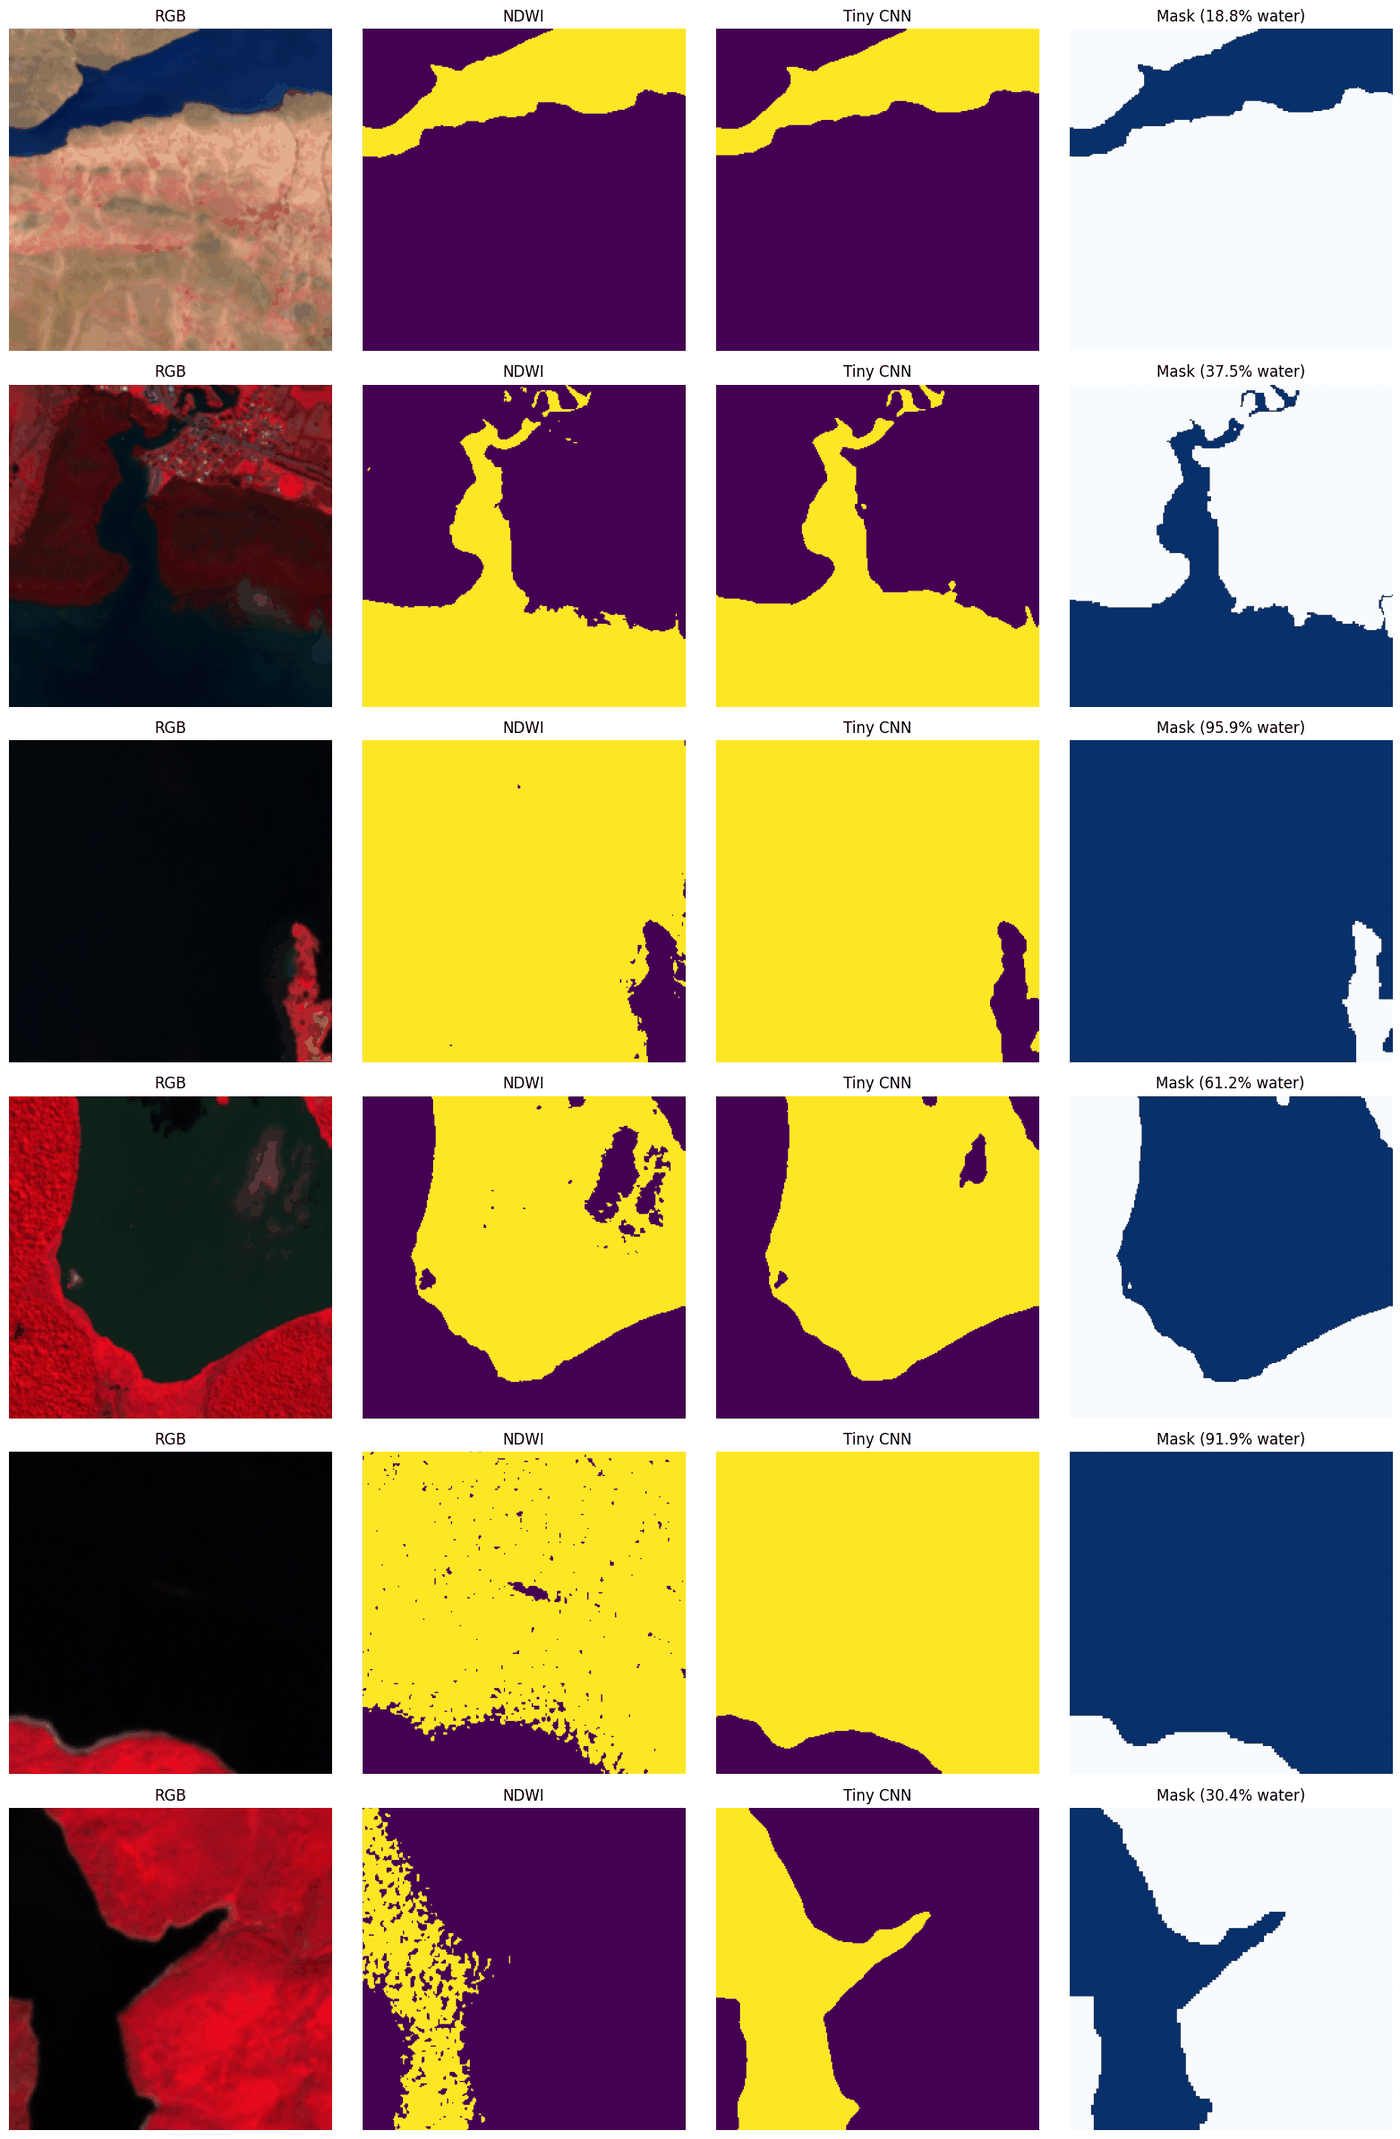

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def collect_water_samples(loader, n_samples=6, min_water_frac=0.01, max_batches=400):
    xs, ys, wfs = [], [], []
    scanned = 0

    for b in loader:
        scanned += 1
        x, y = batch_xy(b)          # x (B,C,H,W)  y (B,1,H,W)
        y_hw = y[:,0]

        water_frac = (y_hw > 0).float().mean(dim=(1,2))

        for i in range(x.shape[0]):
            if water_frac[i] >= min_water_frac:
                xs.append(x[i].cpu())
                ys.append(y_hw[i].cpu())
                wfs.append(float(water_frac[i]))
            if len(xs) >= n_samples:
                print(f"Collected {len(xs)} samples (scanned {scanned} batches)")
                return xs, ys, wfs

        if scanned >= max_batches:
            break

    return xs, ys, wfs


# ---- collect samples ----
tiny.eval()
xs, ys, wfs = collect_water_samples(valid_loader, n_samples=6, min_water_frac=0.01)

fig, axs = plt.subplots(len(xs), 4, figsize=(16, 4*len(xs)))

for i,(x0,y0,wf) in enumerate(zip(xs,ys,wfs)):

    # ---- Tiny CNN prediction ----
    with torch.no_grad():
        prob = torch.sigmoid(tiny(x0.unsqueeze(0).to(device)))[0,0].cpu().numpy()
    pred_tiny = (prob > 0.5).astype(np.uint8)

    # ---- NDWI prediction ----
    ndwi = compute_ndwi(x0)
    pred_ndwi = (ndwi > 0.0).cpu().numpy().astype(np.uint8)

    # ---- RGB ----
    rgb = x0[[3,2,1]].float()
    rgb = (rgb - rgb.min())/(rgb.max()-rgb.min()+1e-6)
    rgb = rgb.permute(1,2,0).numpy()

    axs[i,0].imshow(rgb)
    axs[i,0].set_title("RGB")

    axs[i,1].imshow(pred_ndwi)
    axs[i,1].set_title("NDWI")

    axs[i,2].imshow(pred_tiny)
    axs[i,2].set_title("Tiny CNN")

    axs[i,3].imshow(y0.numpy(), cmap="Blues")
    axs[i,3].set_title(f"Mask ({wf*100:.1f}% water)")

    for j in range(4):
        axs[i,j].axis("off")

plt.tight_layout()
plt.show()

## 7) U‑Net (standard segmentation CNN)

U‑Net = encoder–decoder + skip connections for crisp boundaries.  
TorchGeo provides a U‑Net wrapper (requires `segmentation-models-pytorch`, often installed with TorchGeo).


## 2.2 Why U-Net? The segmentation challenge

Our task is to label **every pixel** — not just say "this image contains water." This is called **semantic segmentation**.

The problem: pooling layers shrink the image to build understanding, but then we need to *expand it back* to make a full-resolution prediction. U-Net solves this with **skip connections** that bridge the shrinking and expanding paths:

```
INPUT (6 bands, 64×64)
       │
  [Conv Block 1] ──────────────────────────────────────► [Conv Block 1']
       │           ↑ skip: "here's the fine detail"  ↑          │
    MaxPool                                          Upsample    │
       │                                                         │
  [Conv Block 2] ──────────────────────────────────► [Conv Block 2']    OUTPUT
       │                  skip                                   │    (1 channel,
    MaxPool                                          Upsample    │     64×64)
       │                                                         │
  [Conv Block 3] ──────────────────────────────────► [Conv Block 3']    
       │                  skip                                   │
    MaxPool                                          Upsample    │
       │                                                         │
       └─────────────── [Bottleneck] ──────────────────────────►┘

  ◄── ENCODER (left)  ──────────────────  DECODER (right) ──►
      learns "what"                        learns "where"
```
- **BCE** (Binary Cross-Entropy): penalizes wrong predictions pixel-by-pixel
**Skip connections** pass high-resolution spatial detail directly from the encoder to the decoder — so the decoder knows *where* the water edges are, not just *that* water exists.

In [ ]:
from torchgeo.models import unet as tg_unet

# build U-Net
unet = tg_unet(in_channels=C, num_classes=1).to(device)

crit_u = nn.BCEWithLogitsLoss()
opt_u = torch.optim.Adam(unet.parameters(), lr=1e-3)

for ep in range(1, 11):
    unet.train()
    losses = []

    for b in train_loader:
        x, y = batch_xy(b)
        x, y = x.to(device), y.to(device)

        opt_u.zero_grad()

        logits = unet(x)      # (B,1,H,W)
        loss = crit_u(logits, y)

        loss.backward()
        opt_u.step()

        losses.append(loss.item())

    print(
        f"U-Net Epoch {ep:02d} | "
        f"loss={np.mean(losses):.4f} | "
        f"val IoU={eval_iou(unet, valid_loader):.3f}"
    )

U-Net Epoch 01 | loss=0.3946 | val IoU=0.441
U-Net Epoch 02 | loss=0.3527 | val IoU=0.763
U-Net Epoch 03 | loss=0.2407 | val IoU=0.561
U-Net Epoch 04 | loss=0.2657 | val IoU=0.557
U-Net Epoch 05 | loss=0.2179 | val IoU=0.805
U-Net Epoch 06 | loss=0.2239 | val IoU=0.796
U-Net Epoch 07 | loss=0.1890 | val IoU=0.868
U-Net Epoch 08 | loss=0.2775 | val IoU=0.849
U-Net Epoch 09 | loss=0.2047 | val IoU=0.537
U-Net Epoch 10 | loss=0.1760 | val IoU=0.579


### Visualize U‑Net prediction

Collected 6 samples (scanned 4 batches)


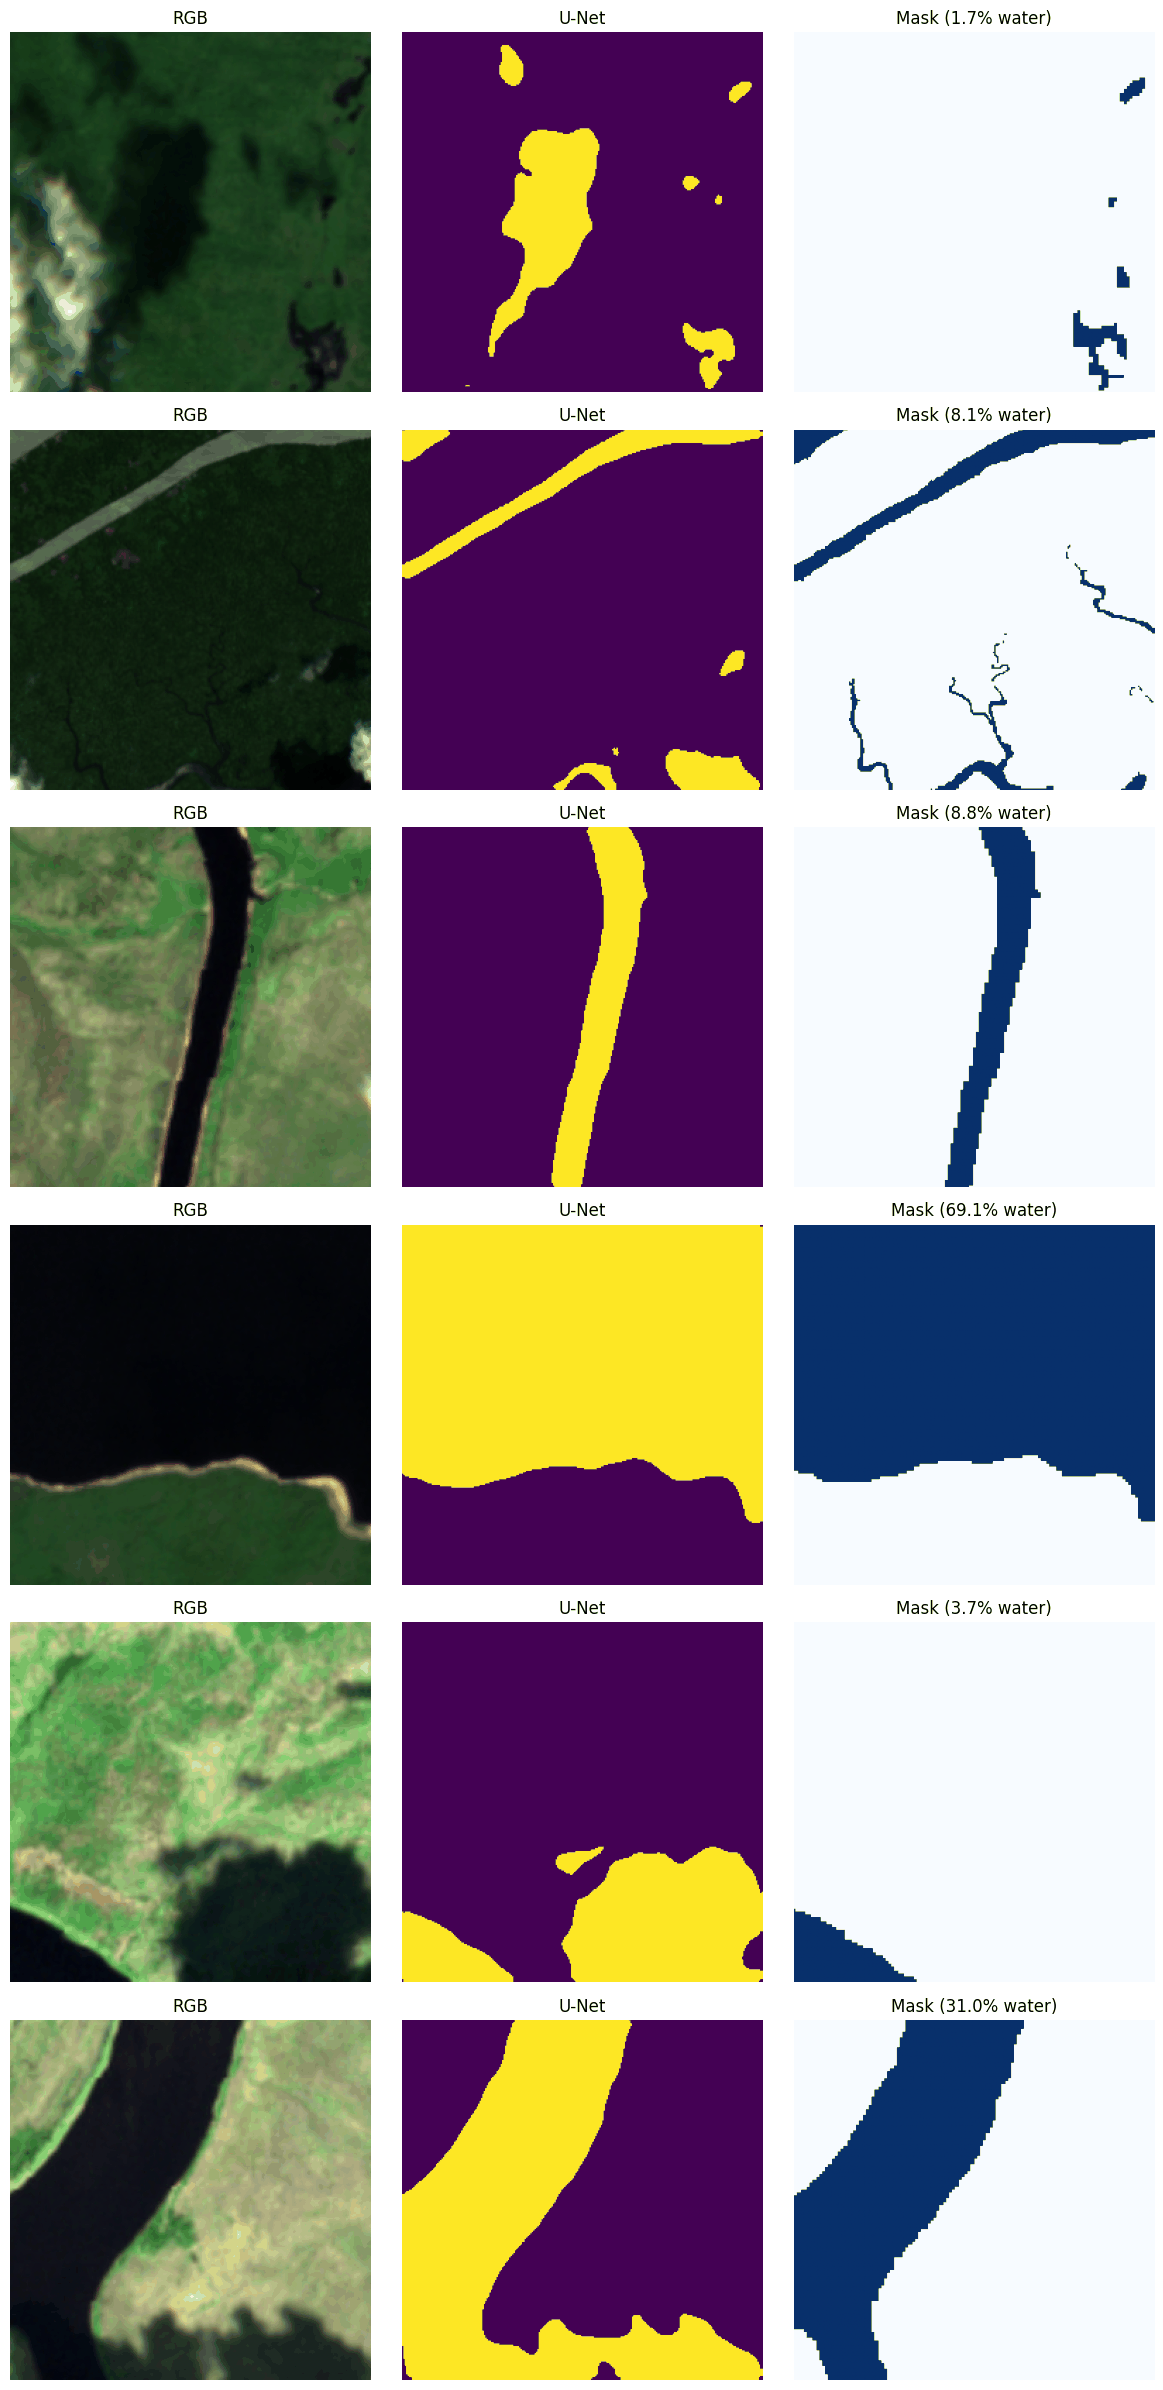

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def collect_water_samples(loader, n_samples=6, min_water_frac=0.01, max_batches=400):
    xs, ys, wfs = [], [], []
    scanned = 0

    for b in loader:
        scanned += 1
        x, y = batch_xy(b)      # x (B,C,H,W), y (B,1,H,W)
        y_hw = y[:,0]

        water_frac = (y_hw > 0).float().mean(dim=(1,2))

        for i in range(x.shape[0]):
            if water_frac[i] >= min_water_frac:
                xs.append(x[i].cpu())
                ys.append(y_hw[i].cpu())
                wfs.append(float(water_frac[i]))

            if len(xs) >= n_samples:
                print(f"Collected {len(xs)} samples (scanned {scanned} batches)")
                return xs, ys, wfs

        if scanned >= max_batches:
            break

    return xs, ys, wfs


# ---- collect samples ----
unet.eval()
xs, ys, wfs = collect_water_samples(valid_loader, n_samples=6)

fig, axs = plt.subplots(len(xs), 3, figsize=(12, 4*len(xs)))

for i,(x0,y0,wf) in enumerate(zip(xs,ys,wfs)):

    # U-Net prediction
    with torch.no_grad():
        prob = torch.sigmoid(unet(x0.unsqueeze(0).to(device)))[0,0].cpu().numpy()
    pred = (prob > 0.5).astype(np.uint8)

    # RGB
    rgb = x0[[2,1,0]].float()
    rgb = (rgb - rgb.min())/(rgb.max()-rgb.min()+1e-6)
    rgb = rgb.permute(1,2,0).numpy()

    axs[i,0].imshow(rgb)
    axs[i,0].set_title("RGB")

    axs[i,1].imshow(pred)
    axs[i,1].set_title("U-Net")

    axs[i,2].imshow(y0.numpy(), cmap="Blues")
    axs[i,2].set_title(f"Mask ({wf*100:.1f}% water)")

    for j in range(3):
        axs[i,j].axis("off")

plt.tight_layout()
plt.show()

## 📚 Resources

| Topic | Link |
|-------|------|
| CNNs visually | [3Blue1Brown — Neural Networks series](https://www.youtube.com/watch?v=aircAruvnKk) |
| U-Net paper | [Ronneberger et al. 2015](https://arxiv.org/abs/1505.04597) |
| TorchGeo | [torchgeo.readthedocs.io](https://torchgeo.readthedocs.io) |
| Landsat band guide | [USGS Landsat 8](https://www.usgs.gov/landsat-missions/landsat-8) |

## 8) Exercises

1. **NDWI threshold sweep**: try thresholds `-0.1, 0.0, 0.1, 0.2` and report IoU.
2. **Capacity**: change `base` in `TinySegCNN` to `16` vs `64`. Explain speed vs accuracy.
3. **Data amount**: change `TRAIN_LEN` to 48 vs 192. Explain what changes.
4. **Failure modes**: show one failure of NDWI and explain why CNN might improve it.

**Stretch:** measure water pixel fraction in a few patches and discuss class imbalance.
